# Personalized Music Recommendation System Using Graph Neural Network on LastFM Dataset

### Kelompok 16
- Ahmad Fariz Khairi - 2306211370
- Gerrardin Nabil Zulhian - 2306250661
- Muhammad Hilmy Mahardika - 2306267006
- Muhammad Dzaky Maulana - 2306264401

Proyek ini dibuat untuk tugas pengganti UAS mata kuliah **Kecerdasan Buatan**.

**Ide utama proyek:**
- Dataset: LastFM listening history
- Problem: rekomendasi artist/musik personal
- Representasi data: graph bipartite **User–Artist**
- Model: **LightGCN**
- Baseline: Popularity-based recommendation
- Evaluasi: Precision@K, Recall@K, dan NDCG@K

> Catatan: Dataset ini tidak punya rating eksplisit, jadi kita bikin sinyal preferensi dari `listen_count`, yaitu jumlah user mendengarkan artist tertentu.


## 1. Setup Library




In [ ]:
import os
import zipfile
import random
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder

import torch
import torch.nn as nn
import torch.nn.functional as F

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Torch version: 2.10.0+cpu
CUDA available: False


## 2. Load Dataset dari ZIP




In [ ]:
# Path default untuk Google Colab
zip_path = "/content/archive.zip"
extract_path = "/content/lastfm_dataset"

# Fallback kalau notebook dijalankan di environment lokal / Jupyter
if not os.path.exists(zip_path) and os.path.exists("/mnt/data/archive.zip"):
    zip_path = "/mnt/data/archive.zip"
    extract_path = "/mnt/data/lastfm_dataset"

# upload manual
if not os.path.exists(zip_path):
    try:
        from google.colab import files
        uploaded = files.upload()
        zip_path = list(uploaded.keys())[0]
        extract_path = "/content/lastfm_dataset"
    except Exception as e:
        raise FileNotFoundError("File archive.zip belum ditemukan. Upload ZIP dataset dulu ya.") from e

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted files:")
print(os.listdir(extract_path))

Saving archive.zip to archive.zip
Extracted files:
['Last.fm_data.csv']


In [ ]:
csv_path = os.path.join(extract_path, "Last.fm_data.csv")

df = pd.read_csv(csv_path)
df.head()

,Unnamed: 0,Username,Artist,Track,Album,Date,Time
0,0,Babs_05,Isobel Campbell,The Circus Is Leaving Town,Ballad of the Broken Seas,31 Jan 2021,23:36
1,1,Babs_05,Isobel Campbell,Dusty Wreath,Ballad of the Broken Seas,31 Jan 2021,23:32
2,2,Babs_05,Isobel Campbell,Honey Child What Can I Do?,Ballad of the Broken Seas,31 Jan 2021,23:28
3,3,Babs_05,Isobel Campbell,It's Hard To Kill A Bad Thing,Ballad of the Broken Seas,31 Jan 2021,23:25
4,4,Babs_05,Isobel Campbell,Saturday's Gone,Ballad of the Broken Seas,31 Jan 2021,23:21


## 3. Exploratory Data Analysis (EDA) Singkat

Bagian ini buat memahami isi dataset dan bisa dipakai sebagai bukti di laporan.


In [ ]:
print("Jumlah baris dan kolom:", df.shape)

print("\nNama kolom:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nJumlah nilai unik per kolom:")
print(df.nunique())

display(df.head(10))

Jumlah baris dan kolom: (166153, 7)

Nama kolom:
['Unnamed: 0', 'Username', 'Artist', 'Track', 'Album', 'Date', 'Time']

Missing values:
Unnamed: 0     0
Username       0
Artist         0
Track          0
Album         12
Date           0
Time           0
dtype: int64

Jumlah nilai unik per kolom:
Unnamed: 0    166153
Username          11
Artist         22823
Track          67241
Album          38629
Date              31
Time            1440
dtype: int64


,Unnamed: 0,Username,Artist,Track,Album,Date,Time
0,0,Babs_05,Isobel Campbell,The Circus Is Leaving Town,Ballad of the Broken Seas,31 Jan 2021,23:36
1,1,Babs_05,Isobel Campbell,Dusty Wreath,Ballad of the Broken Seas,31 Jan 2021,23:32
2,2,Babs_05,Isobel Campbell,Honey Child What Can I Do?,Ballad of the Broken Seas,31 Jan 2021,23:28
3,3,Babs_05,Isobel Campbell,It's Hard To Kill A Bad Thing,Ballad of the Broken Seas,31 Jan 2021,23:25
4,4,Babs_05,Isobel Campbell,Saturday's Gone,Ballad of the Broken Seas,31 Jan 2021,23:21
5,5,Babs_05,Isobel Campbell,(Do You Wanna) Come Walk With Me?,Ballad of the Broken Seas,31 Jan 2021,23:17
6,6,Babs_05,Isobel Campbell,Ramblin' Man,Ballad of the Broken Seas,31 Jan 2021,23:14
7,7,Babs_05,Isobel Campbell,Revolver,Ballad of the Broken Seas,31 Jan 2021,23:11
8,8,Babs_05,Isobel Campbell,Ballad Of The Broken Seas,Ballad of the Broken Seas,31 Jan 2021,23:08
9,9,Babs_05,Isobel Campbell,The False Husband,Ballad of the Broken Seas,31 Jan 2021,23:04


Jumlah user unik: 11
Jumlah artist unik: 22823
Jumlah track unik: 67241


,listening_count,count
0,Babs_05,33695
1,franhale,32712
2,Knapster01,27015
3,eartle,20966
4,massdosage,19015
5,jonocole,17230
6,Orlenay,10123
7,isaac,1780
8,mremond,1452
9,jajo,1102


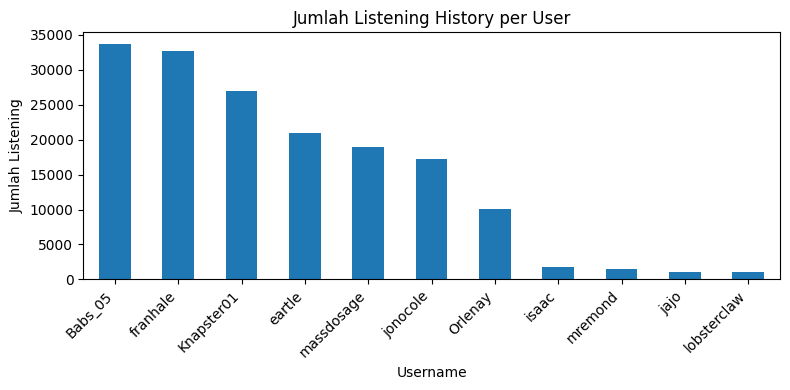

In [ ]:
# Distribusi jumlah listening per user
user_counts = df["Username"].value_counts()

print("Jumlah user unik:", df["Username"].nunique())
print("Jumlah artist unik:", df["Artist"].nunique())
print("Jumlah track unik:", df["Track"].nunique())

display(user_counts.reset_index().rename(columns={"index": "Username", "Username": "listening_count"}).head(20))

plt.figure(figsize=(8, 4))
user_counts.plot(kind="bar")
plt.title("Jumlah Listening History per User")
plt.xlabel("Username")
plt.ylabel("Jumlah Listening")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 4. Data Cleaning

Kolom `Unnamed: 0` tidak dipakai. Kolom `Album`  kosong karena fokus proyek ini adalah relasi **User–Artist**, bukan rekomendasi album.


In [ ]:
df_clean = df.copy()

if "Unnamed: 0" in df_clean.columns:
    df_clean = df_clean.drop(columns=["Unnamed: 0"])

before = len(df_clean)
df_clean = df_clean.drop_duplicates()
after = len(df_clean)

df_clean["Username"] = df_clean["Username"].astype(str)
df_clean["Artist"] = df_clean["Artist"].astype(str)
df_clean["Track"] = df_clean["Track"].astype(str)

print("Jumlah data sebelum drop duplicate:", before)
print("Jumlah data sesudah drop duplicate:", after)
print("Duplikat terhapus:", before - after)

display(df_clean.head())

Jumlah data sebelum drop duplicate: 166153
Jumlah data sesudah drop duplicate: 166153
Duplikat terhapus: 0


,Username,Artist,Track,Album,Date,Time
0,Babs_05,Isobel Campbell,The Circus Is Leaving Town,Ballad of the Broken Seas,31 Jan 2021,23:36
1,Babs_05,Isobel Campbell,Dusty Wreath,Ballad of the Broken Seas,31 Jan 2021,23:32
2,Babs_05,Isobel Campbell,Honey Child What Can I Do?,Ballad of the Broken Seas,31 Jan 2021,23:28
3,Babs_05,Isobel Campbell,It's Hard To Kill A Bad Thing,Ballad of the Broken Seas,31 Jan 2021,23:25
4,Babs_05,Isobel Campbell,Saturday's Gone,Ballad of the Broken Seas,31 Jan 2021,23:21


## 5. Membuat Interaksi User–Artist

Karena tidak ada rating, kita hitung berapa kali seorang user mendengarkan artist tertentu.

Hasilnya menjadi:

```text
Username | Artist | listen_count
```

Data ini nantinya menjadi edge pada graph.


In [ ]:
user_artist = (
    df_clean.groupby(["Username", "Artist"])
    .size()
    .reset_index(name="listen_count")
)

user_artist = user_artist.sort_values("listen_count", ascending=False).reset_index(drop=True)

print("Jumlah interaksi user-artist:", len(user_artist))
display(user_artist.head(15))

Jumlah interaksi user-artist: 51790


,Username,Artist,listen_count
0,Babs_05,Sophie,367
1,franhale,Sophie,292
2,massdosage,Madlib,208
3,Knapster01,Sophie,196
4,Knapster01,Bicep,175
5,Knapster01,Madlib,174
6,Babs_05,Arlo Parks,162
7,eartle,Madlib,142
8,franhale,Metallica,138
9,franhale,Bicep,137


,listen_count
count,51790.000000
mean,3.208206
std,7.052209
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,367.000000


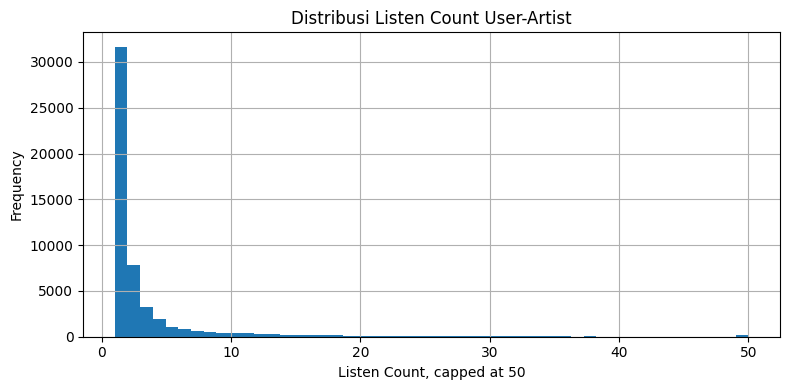

In [ ]:
# Statistik listen_count
display(user_artist["listen_count"].describe())

plt.figure(figsize=(8, 4))
user_artist["listen_count"].clip(upper=50).hist(bins=50)
plt.title("Distribusi Listen Count User-Artist")
plt.xlabel("Listen Count, capped at 50")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## 6. Encode User dan Artist

Model machine learning tidak langsung membaca nama user/artist. Jadi kita ubah menjadi indeks numerik.


In [ ]:
user_encoder = LabelEncoder()
artist_encoder = LabelEncoder()

user_artist["user_id"] = user_encoder.fit_transform(user_artist["Username"])
user_artist["artist_id"] = artist_encoder.fit_transform(user_artist["Artist"])

num_users = user_artist["user_id"].nunique()
num_artists = user_artist["artist_id"].nunique()
num_interactions = len(user_artist)

print("Jumlah user:", num_users)
print("Jumlah artist:", num_artists)
print("Jumlah interaksi:", num_interactions)

display(user_artist.head())

Jumlah user: 11
Jumlah artist: 22823
Jumlah interaksi: 51790


,Username,Artist,listen_count,user_id,artist_id
0,Babs_05,Sophie,367,0,17637
1,franhale,Sophie,292,4,17637
2,massdosage,Madlib,208,9,11976
3,Knapster01,Sophie,196,1,17637
4,Knapster01,Bicep,175,1,2112


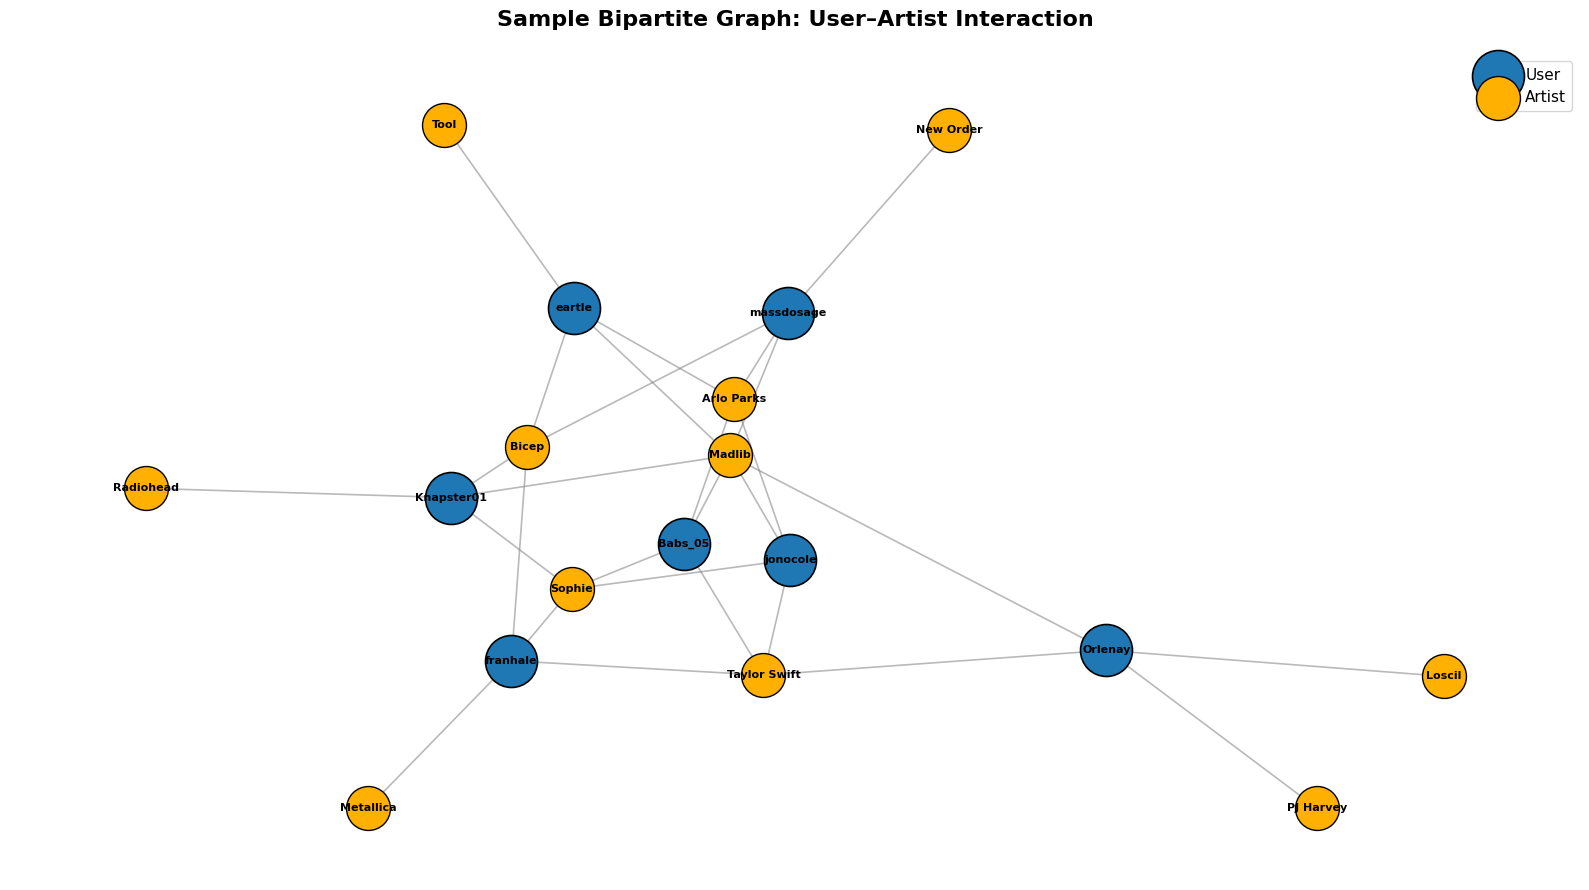

In [ ]:
# Visualisasi Graph User-Artist yang lebih rapi dan menarik

import networkx as nx
import matplotlib.pyplot as plt

# Ambil sampel kecil agar graph mudah dibaca
sample_users = (
    user_artist.groupby("Username")
    .size()
    .sort_values(ascending=False)
    .head(7)
    .index
)

graph_sample = user_artist[user_artist["Username"].isin(sample_users)].copy()

# Ambil top artist per user berdasarkan listen_count
graph_sample = (
    graph_sample.sort_values(["Username", "listen_count"], ascending=[True, False])
    .groupby("Username")
    .head(4)
)

G = nx.Graph()

for _, row in graph_sample.iterrows():
    user_node = f"User: {row['Username']}"
    artist_node = f"Artist: {row['Artist']}"

    G.add_node(user_node, node_type="user")
    G.add_node(artist_node, node_type="artist")
    G.add_edge(user_node, artist_node, weight=row["listen_count"])

plt.figure(figsize=(16, 9))

pos = nx.spring_layout(G, seed=42, k=1.2)

user_nodes = [n for n, d in G.nodes(data=True) if d["node_type"] == "user"]
artist_nodes = [n for n, d in G.nodes(data=True) if d["node_type"] == "artist"]

nx.draw_networkx_nodes(
    G, pos,
    nodelist=user_nodes,
    node_color="#1f77b4",
    node_size=1400,
    edgecolors="black",
    linewidths=1.2,
    label="User"
)

nx.draw_networkx_nodes(
    G, pos,
    nodelist=artist_nodes,
    node_color="#ffb000",
    node_size=1000,
    edgecolors="black",
    linewidths=1.0,
    label="Artist"
)

# Edge
nx.draw_networkx_edges(
    G, pos,
    width=1.2,
    alpha=0.55,
    edge_color="gray"
)

# Label lebih pendek
labels = {}
for node in G.nodes():
    labels[node] = node.replace("User: ", "").replace("Artist: ", "")

nx.draw_networkx_labels(
    G, pos,
    labels=labels,
    font_size=8,
    font_weight="bold"
)

plt.title(
    "Sample Bipartite Graph: User–Artist Interaction",
    fontsize=16,
    fontweight="bold",
    pad=20
)

plt.legend(
    scatterpoints=1,
    loc="upper right",
    fontsize=11,
    frameon=True
)

plt.axis("off")
plt.tight_layout()
plt.show()

## 7. Train-Test Split

Kita split per user agar setiap user tetap punya data train dan test.  
Data test dipakai untuk mengecek apakah sistem bisa merekomendasikan artist yang memang muncul di data asli user.


In [ ]:
def split_train_test_per_user(data, test_ratio=0.2, seed=42):
    rng = np.random.default_rng(seed)
    train_parts = []
    test_parts = []

    for user_id, group in data.groupby("user_id"):
        group = group.sample(frac=1, random_state=seed).reset_index(drop=True)

        if len(group) < 5:
            # Kalau interaksi user terlalu sedikit, ambil 1 untuk test
            n_test = 1
        else:
            n_test = max(1, int(len(group) * test_ratio))

        test_idx = rng.choice(group.index, size=n_test, replace=False)
        test_group = group.loc[test_idx]
        train_group = group.drop(test_idx)

        train_parts.append(train_group)
        test_parts.append(test_group)

    train_df = pd.concat(train_parts).reset_index(drop=True)
    test_df = pd.concat(test_parts).reset_index(drop=True)

    return train_df, test_df

train_df, test_df = split_train_test_per_user(user_artist, test_ratio=0.2, seed=SEED)

print("Train interactions:", len(train_df))
print("Test interactions:", len(test_df))
print("Train users:", train_df["user_id"].nunique())
print("Test users:", test_df["user_id"].nunique())

display(train_df.head())
display(test_df.head())

Train interactions: 41438
Test interactions: 10352
Train users: 11
Test users: 11


,Username,Artist,listen_count,user_id,artist_id
0,Babs_05,Home Free,4,0,8167
1,Babs_05,Soft Slipper,1,0,17542
2,Babs_05,Weekend Wolves,1,0,21243
3,Babs_05,Sam Fender,8,0,16623
4,Babs_05,Palace,2,0,14601


,Username,Artist,listen_count,user_id,artist_id
0,Babs_05,Arcade Fire,68,0,1234
1,Babs_05,Desireless,1,0,5015
2,Babs_05,Coconut Records,1,0,3873
3,Babs_05,Guillaume Perret & Electric Epic,3,0,7605
4,Babs_05,Velcra,2,0,20882


## 8. Baseline: Popularity-Based Recommendation

Baseline ini merekomendasikan artist yang paling populer di data train.  
Ini penting sebagai pembanding, supaya model GNN kita tidak berdiri sendirian.


In [ ]:
def build_user_items_dict(data):
    return data.groupby("user_id")["artist_id"].apply(set).to_dict()

train_user_items = build_user_items_dict(train_df)
test_user_items = build_user_items_dict(test_df)

artist_popularity = (
    train_df.groupby("artist_id")["listen_count"]
    .sum()
    .sort_values(ascending=False)
)

popular_artists = artist_popularity.index.tolist()

def recommend_popularity(user_id, k=10):
    seen = train_user_items.get(user_id, set())
    recs = [artist for artist in popular_artists if artist not in seen]
    return recs[:k]

def precision_recall_ndcg_at_k(recommended, relevant, k=10):
    recommended = recommended[:k]
    relevant = set(relevant)

    if len(relevant) == 0:
        return 0.0, 0.0, 0.0

    hits = [1 if item in relevant else 0 for item in recommended]
    precision = sum(hits) / k
    recall = sum(hits) / len(relevant)

    dcg = sum(hit / math.log2(idx + 2) for idx, hit in enumerate(hits))
    ideal_hits = [1] * min(len(relevant), k)
    idcg = sum(hit / math.log2(idx + 2) for idx, hit in enumerate(ideal_hits))
    ndcg = dcg / idcg if idcg > 0 else 0.0

    return precision, recall, ndcg

def evaluate_recommender(recommend_func, users, k=10):
    precisions, recalls, ndcgs = [], [], []

    for user_id in users:
        relevant = test_user_items.get(user_id, set())
        recommended = recommend_func(user_id, k=k)

        p, r, n = precision_recall_ndcg_at_k(recommended, relevant, k)
        precisions.append(p)
        recalls.append(r)
        ndcgs.append(n)

    return {
        f"Precision@{k}": float(np.mean(precisions)),
        f"Recall@{k}": float(np.mean(recalls)),
        f"NDCG@{k}": float(np.mean(ndcgs))
    }

eval_users = sorted(test_df["user_id"].unique())

baseline_result = evaluate_recommender(recommend_popularity, eval_users, k=10)
baseline_result

{'Precision@10': 0.6454545454545454,
 'Recall@10': 0.011840310358245868,
 'NDCG@10': 0.6607357518244155}

## 9. Membuat Graph untuk LightGCN

Graph yang dibuat adalah graph bipartite:

```text
User node ─── listens_to ─── Artist node
```

Agar ID user dan artist tidak bentrok:
- User node: `0` sampai `num_users - 1`
- Artist node: `num_users` sampai `num_users + num_artists - 1`


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_nodes = num_users + num_artists

# Edge dari train data saja
user_nodes = torch.tensor(train_df["user_id"].values, dtype=torch.long)
artist_nodes = torch.tensor(train_df["artist_id"].values + num_users, dtype=torch.long)

# Undirected graph: user -> artist dan artist -> user
edge_index = torch.cat([
    torch.stack([user_nodes, artist_nodes], dim=0),
    torch.stack([artist_nodes, user_nodes], dim=0)
], dim=1)

print("Total nodes:", num_nodes)
print("Edge index shape:", edge_index.shape)
print("Device:", device)

Total nodes: 22834
Edge index shape: torch.Size([2, 82876])
Device: cpu


In [ ]:
def build_norm_adj(edge_index, num_nodes):
    row, col = edge_index

    deg = torch.bincount(row, minlength=num_nodes).float()
    deg_inv_sqrt = deg.pow(-0.5)
    deg_inv_sqrt[torch.isinf(deg_inv_sqrt)] = 0.0

    values = deg_inv_sqrt[row] * deg_inv_sqrt[col]

    adj = torch.sparse_coo_tensor(
        edge_index,
        values,
        size=(num_nodes, num_nodes)
    )

    return adj.coalesce()

norm_adj = build_norm_adj(edge_index, num_nodes).to(device)
print(norm_adj)

tensor(indices=tensor([[    0,     0,     0,  ..., 22831, 22832, 22833],
                       [   17,    18,    21,  ...,     1,     4,     4]]),
       values=tensor([0.0047, 0.0052, 0.0058,  ..., 0.0088, 0.0115, 0.0115]),
       size=(22834, 22834), nnz=82876, layout=torch.sparse_coo)


## 10. Model LightGCN

LightGCN mempelajari embedding user dan artist dari struktur graph.  
Skor rekomendasi dihitung dari dot product antara embedding user dan embedding artist.


In [ ]:
class LightGCN(nn.Module):
    def __init__(self, num_users, num_artists, embedding_dim=64, num_layers=2):
        super().__init__()
        self.num_users = num_users
        self.num_artists = num_artists
        self.num_nodes = num_users + num_artists
        self.embedding_dim = embedding_dim
        self.num_layers = num_layers

        self.embedding = nn.Embedding(self.num_nodes, embedding_dim)
        nn.init.xavier_uniform_(self.embedding.weight)

    def propagate(self, norm_adj):
        all_embeddings = self.embedding.weight
        embeddings_per_layer = [all_embeddings]

        for _ in range(self.num_layers):
            all_embeddings = torch.sparse.mm(norm_adj, all_embeddings)
            embeddings_per_layer.append(all_embeddings)

        final_embeddings = torch.mean(torch.stack(embeddings_per_layer, dim=0), dim=0)

        user_emb = final_embeddings[:self.num_users]
        artist_emb = final_embeddings[self.num_users:]

        return user_emb, artist_emb

    def forward(self, users, pos_artists, neg_artists, norm_adj):
        user_emb, artist_emb = self.propagate(norm_adj)

        u = user_emb[users]
        pos = artist_emb[pos_artists]
        neg = artist_emb[neg_artists]

        pos_scores = torch.sum(u * pos, dim=1)
        neg_scores = torch.sum(u * neg, dim=1)

        return pos_scores, neg_scores

def bpr_loss(pos_scores, neg_scores):
    return -torch.mean(F.logsigmoid(pos_scores - neg_scores))

## 11. Training LightGCN

Training menggunakan **BPR Loss**.  
Konsepnya: untuk setiap user, skor artist yang pernah didengar harus lebih tinggi dari artist random yang belum pernah didengar.


In [ ]:
all_artist_ids = set(range(num_artists))

def sample_negative(user_id):
    seen = train_user_items.get(int(user_id), set())
    while True:
        neg = random.randint(0, num_artists - 1)
        if neg not in seen:
            return neg

train_pairs = train_df[["user_id", "artist_id"]].values

def get_batch(train_pairs, batch_size=1024):
    idx = np.random.choice(len(train_pairs), size=batch_size, replace=True)
    batch = train_pairs[idx]

    users = batch[:, 0]
    pos_artists = batch[:, 1]
    neg_artists = np.array([sample_negative(u) for u in users])

    return (
        torch.tensor(users, dtype=torch.long, device=device),
        torch.tensor(pos_artists, dtype=torch.long, device=device),
        torch.tensor(neg_artists, dtype=torch.long, device=device)
    )

model = LightGCN(
    num_users=num_users,
    num_artists=num_artists,
    embedding_dim=64,
    num_layers=2
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 30
batch_size = 1024
steps_per_epoch = max(1, len(train_pairs) // batch_size)

loss_history = []

for epoch in range(1, epochs + 1):
    model.train()
    total_loss = 0.0

    for _ in range(steps_per_epoch):
        users, pos_artists, neg_artists = get_batch(train_pairs, batch_size=batch_size)

        optimizer.zero_grad()
        pos_scores, neg_scores = model(users, pos_artists, neg_artists, norm_adj)
        loss = bpr_loss(pos_scores, neg_scores)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / steps_per_epoch
    loss_history.append(avg_loss)

    if epoch == 1 or epoch % 5 == 0:
        print(f"Epoch {epoch:02d} | Loss: {avg_loss:.4f}")

Epoch 01 | Loss: 0.6592
Epoch 05 | Loss: 0.1977
Epoch 10 | Loss: 0.0984
Epoch 15 | Loss: 0.0626
Epoch 20 | Loss: 0.0426
Epoch 25 | Loss: 0.0314
Epoch 30 | Loss: 0.0230


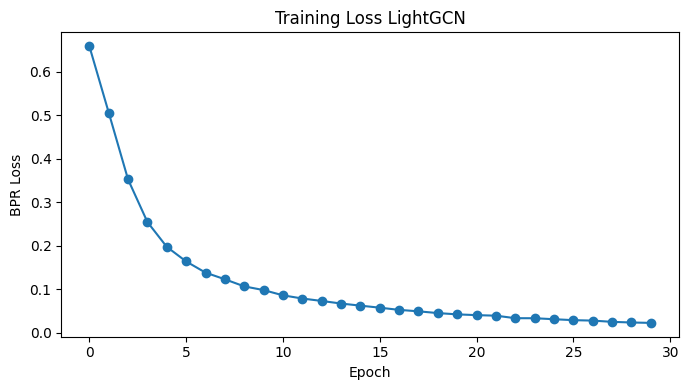

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(loss_history, marker="o")
plt.title("Training Loss LightGCN")
plt.xlabel("Epoch")
plt.ylabel("BPR Loss")
plt.tight_layout()
plt.show()

## 12. Evaluasi LightGCN

Evaluasi dilakukan dengan cara:
1. Hitung skor semua artist untuk setiap user.
2. Artist yang sudah ada di train disembunyikan agar tidak direkomendasikan ulang.
3. Ambil Top-K artist.
4. Bandingkan dengan artist pada data test.


In [ ]:
@torch.no_grad()
def get_lightgcn_recommendations(user_id, k=10):
    model.eval()
    user_emb, artist_emb = model.propagate(norm_adj)

    user_vector = user_emb[user_id]
    scores = torch.matmul(artist_emb, user_vector)

    scores = scores.detach().cpu().numpy()

    # tidak merekomendasikan artist yang sudah ada di train
    seen = train_user_items.get(user_id, set())
    scores[list(seen)] = -np.inf

    top_k = np.argpartition(-scores, kth=k)[:k]
    top_k = top_k[np.argsort(-scores[top_k])]

    return top_k.tolist()

lightgcn_result = evaluate_recommender(get_lightgcn_recommendations, eval_users, k=10)
lightgcn_result

{'Precision@10': 0.781818181818182,
 'Recall@10': 0.03902549274977149,
 'NDCG@10': 0.7985059336530976}

## 13. Perbandingan Baseline vs LightGCN

In [ ]:
results_df = pd.DataFrame([
    {"Model": "Popularity-Based", **baseline_result},
    {"Model": "LightGCN", **lightgcn_result}
])

display(results_df)

results_df.to_csv("experiment_results.csv", index=False)
print("Saved: experiment_results.csv")

,Model,Precision@10,Recall@10,NDCG@10
0,Popularity-Based,0.645455,0.011840,0.660736
1,LightGCN,0.781818,0.039025,0.798506


Saved: experiment_results.csv


## 14. Contoh Rekomendasi Artist

bukti hasil sistem rekomendasi.


In [ ]:
def decode_artist(artist_id):
    return artist_encoder.inverse_transform([artist_id])[0]

def decode_user(user_id):
    return user_encoder.inverse_transform([user_id])[0]

sample_users = eval_users[:5]

recommendation_rows = []

for user_id in sample_users:
    rec_ids = get_lightgcn_recommendations(user_id, k=10)
    rec_names = [decode_artist(aid) for aid in rec_ids]

    recommendation_rows.append({
        "user_id": user_id,
        "username": decode_user(user_id),
        "top_10_recommended_artists": ", ".join(rec_names)
    })

recommendation_df = pd.DataFrame(recommendation_rows)
display(recommendation_df)

recommendation_df.to_csv("sample_recommendations.csv", index=False)
print("Saved: sample_recommendations.csv")

,user_id,username,top_10_recommended_artists
0,0,Babs_05,"Tangerine Dream, Sol Calor, Bibio, Nursery Rhy..."
1,1,Knapster01,"Kriget, The Heptones, Children of Bodom, Natas..."
2,2,Orlenay,"Taylor Swift, Kino, Fela Kuti, Tangerine Dream..."
3,3,eartle,"Toquinho, STRFKR, Apocalyptica, Coldcut, Siren..."
4,4,franhale,The Presidents of the United States of America...


Saved: sample_recommendations.csv


## 15. Save Processed Dataset dan Metadata

File ini bisa dilampirkan ke GitHub/Google Drive.


In [ ]:
processed_path = "user_artist_interactions.csv"
user_artist.to_csv(processed_path, index=False)

metadata = {
    "project_title": "Personalized Music Recommendation System Using Graph Neural Network on LastFM Dataset",
    "dataset": "LastFM Dataset from Kaggle",
    "total_rows_raw": int(len(df)),
    "total_users": int(num_users),
    "total_artists": int(num_artists),
    "total_user_artist_interactions": int(num_interactions),
    "model": "LightGCN",
    "baseline": "Popularity-Based Recommendation",
    "metrics": ["Precision@10", "Recall@10", "NDCG@10"],
    "status": "initial experiment completed"
}

import json
with open("metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved:", processed_path)
print("Saved: metadata.json")
print(json.dumps(metadata, indent=2))

Saved: user_artist_interactions.csv
Saved: metadata.json
{
  "project_title": "Personalized Music Recommendation System Using Graph Neural Network on LastFM Dataset",
  "dataset": "LastFM Dataset from Kaggle",
  "total_rows_raw": 166153,
  "total_users": 11,
  "total_artists": 22823,
  "total_user_artist_interactions": 51790,
  "model": "LightGCN",
  "baseline": "Popularity-Based Recommendation",
  "metrics": [
    "Precision@10",
    "Recall@10",
    "NDCG@10"
  ],
  "status": "initial experiment completed"
}


In [ ]:
# Hyperparameter Tuning LightGCN

tuning_configs = [
    {
        "config_name": "LightGCN_dim32_layer2",
        "embedding_dim": 32,
        "num_layers": 2,
        "learning_rate": 0.001,
        "epochs": 30,
        "batch_size": 1024
    },
    {
        "config_name": "LightGCN_dim64_layer2",
        "embedding_dim": 64,
        "num_layers": 2,
        "learning_rate": 0.001,
        "epochs": 30,
        "batch_size": 1024
    },
    {
        "config_name": "LightGCN_dim128_layer2",
        "embedding_dim": 128,
        "num_layers": 2,
        "learning_rate": 0.001,
        "epochs": 30,
        "batch_size": 1024
    },
    {
        "config_name": "LightGCN_dim64_layer1",
        "embedding_dim": 64,
        "num_layers": 1,
        "learning_rate": 0.001,
        "epochs": 30,
        "batch_size": 1024
    },
    {
        "config_name": "LightGCN_dim64_layer3",
        "embedding_dim": 64,
        "num_layers": 3,
        "learning_rate": 0.001,
        "epochs": 30,
        "batch_size": 1024
    }
]


def train_lightgcn_config(config):
    """
    Training LightGCN untuk satu konfigurasi hyperparameter.
    Return: model, loss_history, final_loss
    """

    # Reset seed agar hasil lebih reproducible
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)

    model = LightGCN(
        num_users=num_users,
        num_artists=num_artists,
        embedding_dim=config["embedding_dim"],
        num_layers=config["num_layers"]
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=config["learning_rate"]
    )

    epochs = config["epochs"]
    batch_size = config["batch_size"]
    steps_per_epoch = max(1, len(train_pairs) // batch_size)

    loss_history = []

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0

        for _ in range(steps_per_epoch):
            users, pos_artists, neg_artists = get_batch(
                train_pairs,
                batch_size=batch_size
            )

            optimizer.zero_grad()
            pos_scores, neg_scores = model(
                users,
                pos_artists,
                neg_artists,
                norm_adj
            )

            loss = bpr_loss(pos_scores, neg_scores)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / steps_per_epoch
        loss_history.append(avg_loss)

        if epoch == 1 or epoch % 10 == 0 or epoch == epochs:
            print(
                f"{config['config_name']} | "
                f"Epoch {epoch:02d}/{epochs} | "
                f"Loss: {avg_loss:.4f}"
            )

    return model, loss_history, loss_history[-1]


@torch.no_grad()
def get_lightgcn_recommendations_from_model(trained_model, user_id, k=10):
    """
    Menghasilkan rekomendasi dari model LightGCN tertentu.
    Dipakai untuk evaluasi hasil tuning.
    """

    trained_model.eval()

    user_emb, artist_emb = trained_model.propagate(norm_adj)

    user_vector = user_emb[user_id]
    scores = torch.matmul(artist_emb, user_vector)
    scores = scores.detach().cpu().numpy()

    # Jangan rekomendasikan artist yang sudah muncul di data train
    seen = train_user_items.get(user_id, set())
    scores[list(seen)] = -np.inf

    top_k = np.argpartition(-scores, kth=k)[:k]
    top_k = top_k[np.argsort(-scores[top_k])]

    return top_k.tolist()


def evaluate_lightgcn_model(trained_model, users, k=10):
    """
    Evaluasi model LightGCN tertentu dengan Precision@K, Recall@K, NDCG@K.
    """

    def recommend_func(user_id, k=10):
        return get_lightgcn_recommendations_from_model(
            trained_model,
            user_id,
            k=k
        )

    return evaluate_recommender(recommend_func, users, k=k)

In [ ]:
# Run Hyperparameter Tuning

tuning_results = []
trained_models = {}
loss_histories = {}

for config in tuning_configs:
    print("=" * 80)
    print("Running:", config["config_name"])
    print("=" * 80)

    tuned_model, tuned_loss_history, final_loss = train_lightgcn_config(config)

    eval_result = evaluate_lightgcn_model(
        tuned_model,
        eval_users,
        k=10
    )

    result_row = {
        "Model": config["config_name"],
        "Embedding Dim": config["embedding_dim"],
        "Num Layers": config["num_layers"],
        "Learning Rate": config["learning_rate"],
        "Epochs": config["epochs"],
        "Batch Size": config["batch_size"],
        "Final Loss": final_loss,
        **eval_result
    }

    tuning_results.append(result_row)

    trained_models[config["config_name"]] = tuned_model
    loss_histories[config["config_name"]] = tuned_loss_history

tuning_results_df = pd.DataFrame(tuning_results)

display(tuning_results_df)

tuning_results_df.to_csv("hyperparameter_tuning_results.csv", index=False)
print("Saved: hyperparameter_tuning_results.csv")

Running: LightGCN_dim32_layer2
LightGCN_dim32_layer2 | Epoch 01/30 | Loss: 0.6762
LightGCN_dim32_layer2 | Epoch 10/30 | Loss: 0.1412
LightGCN_dim32_layer2 | Epoch 20/30 | Loss: 0.0603
LightGCN_dim32_layer2 | Epoch 30/30 | Loss: 0.0304
Running: LightGCN_dim64_layer2
LightGCN_dim64_layer2 | Epoch 01/30 | Loss: 0.6592
LightGCN_dim64_layer2 | Epoch 10/30 | Loss: 0.0984
LightGCN_dim64_layer2 | Epoch 20/30 | Loss: 0.0426
LightGCN_dim64_layer2 | Epoch 30/30 | Loss: 0.0230
Running: LightGCN_dim128_layer2
LightGCN_dim128_layer2 | Epoch 01/30 | Loss: 0.6293
LightGCN_dim128_layer2 | Epoch 10/30 | Loss: 0.0581
LightGCN_dim128_layer2 | Epoch 20/30 | Loss: 0.0168
LightGCN_dim128_layer2 | Epoch 30/30 | Loss: 0.0071
Running: LightGCN_dim64_layer1
LightGCN_dim64_layer1 | Epoch 01/30 | Loss: 0.6598
LightGCN_dim64_layer1 | Epoch 10/30 | Loss: 0.0749
LightGCN_dim64_layer1 | Epoch 20/30 | Loss: 0.0215
LightGCN_dim64_layer1 | Epoch 30/30 | Loss: 0.0094
Running: LightGCN_dim64_layer3
LightGCN_dim64_layer3 | 

,Model,Embedding Dim,Num Layers,Learning Rate,Epochs,Batch Size,Final Loss,Precision@10,Recall@10,NDCG@10
0,LightGCN_dim32_layer2,32,2,0.001,30,1024,0.030372,0.818182,0.039309,0.831504
1,LightGCN_dim64_layer2,64,2,0.001,30,1024,0.022970,0.781818,0.039025,0.798506
2,LightGCN_dim128_layer2,128,2,0.001,30,1024,0.007112,0.827273,0.039303,0.822904
3,LightGCN_dim64_layer1,64,1,0.001,30,1024,0.009433,0.781818,0.039005,0.806614
4,LightGCN_dim64_layer3,64,3,0.001,30,1024,0.055522,0.827273,0.039307,0.845210


Saved: hyperparameter_tuning_results.csv


In [ ]:
# Best Model Selection

best_result = tuning_results_df.sort_values(
    by="NDCG@10",
    ascending=False
).iloc[0]

best_model_name = best_result["Model"]
best_model = trained_models[best_model_name]

print("Best model based on NDCG@10:")
display(best_result)

print("Best model name:", best_model_name)

Best model based on NDCG@10:


,4
Model,LightGCN_dim64_layer3
Embedding Dim,64
Num Layers,3
Learning Rate,0.001
Epochs,30
Batch Size,1024
Final Loss,0.055522
Precision@10,0.827273
Recall@10,0.039307
NDCG@10,0.84521


Best model name: LightGCN_dim64_layer3


In [ ]:
# WEB DEMO
# Personalized Music Recommendation System
# LightGCN on LastFM Dataset

!pip install gradio -q

import gradio as gr
import pandas as pd
import numpy as np
import torch

# Helper Function

def get_recommendations_for_demo(user_id, k=10):
    """
    Fungsi rekomendasi utama untuk web demo.
    Jika best_model tersedia dari hyperparameter tuning, gunakan best_model.
    Jika tidak, gunakan model LightGCN awal.
    """

    # Jika sudah ada best_model dari hyperparameter tuning
    if "best_model" in globals():
        best_model.eval()

        with torch.no_grad():
            user_emb, artist_emb = best_model.propagate(norm_adj)

            user_vector = user_emb[user_id]
            scores = torch.matmul(artist_emb, user_vector)
            scores = scores.detach().cpu().numpy()

            # Jangan rekomendasikan artist yang sudah ada di data train
            seen = train_user_items.get(user_id, set())
            scores[list(seen)] = -np.inf

            top_k = np.argpartition(-scores, kth=k)[:k]
            top_k = top_k[np.argsort(-scores[top_k])]

            return top_k.tolist()

    # Jika belum ada best_model, gunakan fungsi rekomendasi LightGCN biasa
    else:
        return get_lightgcn_recommendations(user_id, k=k)


def recommend_for_user(username, top_k):
    """
    Menghasilkan rekomendasi artist berdasarkan username yang dipilih.
    """

    try:
        # Ubah username menjadi user_id
        user_id = int(user_encoder.transform([username])[0])

        # Ambil rekomendasi artist dari model
        rec_ids = get_recommendations_for_demo(user_id, k=int(top_k))

        # Decode artist_id menjadi nama artist
        rec_names = [decode_artist(aid) for aid in rec_ids]

        # Buat tabel hasil rekomendasi
        result_df = pd.DataFrame({
            "Rank": list(range(1, len(rec_names) + 1)),
            "Recommended Artist": rec_names
        })

        return result_df

    except Exception as e:
        return pd.DataFrame({
            "Rank": ["Error"],
            "Recommended Artist": [str(e)]
        })


def show_user_history(username):
    """
    Menampilkan 10 artist yang paling sering didengarkan oleh user
    berdasarkan data asli LastFM.
    """

    try:
        user_history = (
            user_artist[user_artist["Username"] == username]
            .sort_values("listen_count", ascending=False)
            .head(10)[["Artist", "listen_count"]]
            .reset_index(drop=True)
        )

        user_history.insert(0, "Rank", range(1, len(user_history) + 1))

        return user_history

    except Exception as e:
        return pd.DataFrame({
            "Rank": ["Error"],
            "Artist": [str(e)],
            "listen_count": ["-"]
        })


def get_model_info():
    """
    Menampilkan informasi model yang sedang dipakai.
    """

    if "best_model" in globals() and "best_model_name" in globals():
        model_used = f"Best Tuned LightGCN ({best_model_name})"
    else:
        model_used = "Default LightGCN"

    info = f"""
    Model yang digunakan: {model_used}

    Dataset: LastFM Dataset
    Graph: Bipartite User–Artist Graph
    Recommendation Type: Top-K Artist Recommendation
    Evaluation Metrics: Precision@10, Recall@10, NDCG@10
    """

    return info


# User Options

user_options = sorted(list(user_encoder.classes_))


# Gradio Interface

with gr.Blocks(title="LightGCN Music Recommendation System") as demo:

    gr.Markdown(
        """
        # 🎵 Personalized Music Recommendation System
        ### Using Graph Neural Network / LightGCN on LastFM Dataset

        Sistem ini merekomendasikan artist berdasarkan riwayat listening user.
        Dataset direpresentasikan sebagai graph bipartite **User–Artist**, lalu model **LightGCN** digunakan untuk mempelajari embedding user dan artist.
        """
    )

    with gr.Row():
        username_input = gr.Dropdown(
            choices=user_options,
            value=user_options[0],
            label="Pilih Username"
        )

        top_k_input = gr.Slider(
            minimum=5,
            maximum=20,
            value=10,
            step=1,
            label="Jumlah Rekomendasi Top-K"
        )

    with gr.Row():
        recommend_button = gr.Button("Generate Recommendation 🚀")
        history_button = gr.Button("Show User Listening History 🎧")
        info_button = gr.Button("Show Model Info ℹ️")

    with gr.Row():
        recommendation_output = gr.Dataframe(
            headers=["Rank", "Recommended Artist"],
            label="Top-K Recommended Artists",
            interactive=False
        )

        history_output = gr.Dataframe(
            headers=["Rank", "Artist", "listen_count"],
            label="Top-10 User Listening History",
            interactive=False
        )

    model_info_output = gr.Textbox(
        label="Model Information",
        lines=6,
        interactive=False
    )

    recommend_button.click(
        fn=recommend_for_user,
        inputs=[username_input, top_k_input],
        outputs=recommendation_output
    )

    history_button.click(
        fn=show_user_history,
        inputs=username_input,
        outputs=history_output
    )

    info_button.click(
        fn=get_model_info,
        inputs=None,
        outputs=model_info_output
    )

    gr.Markdown(
        """
        ---
        **Cara membaca demo:**
        - Tabel kanan menunjukkan artist yang pernah didengarkan user berdasarkan dataset asli.
        - Tabel kiri menunjukkan artist yang direkomendasikan oleh model LightGCN.
        - Rekomendasi dibuat berdasarkan embedding user dan artist yang dipelajari dari graph User–Artist.
        """
    )

# Launch Demo

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ef02229d7834940f40.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
